In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize


In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SHREE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SHREE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import joblib

In [4]:
import os

print(os.getcwd())

c:\Users\SHREE\Disaster_Tweet_Classification\notebooks


In [5]:
import pandas as pd

df = pd.read_csv("../Data/twitter_disaster (1).csv")

print("Shape:", df.shape)
df.head()


Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [6]:
df.info()
df.isnull().sum()
df.head()
df.columns


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


Index(['id', 'keyword', 'location', 'text', 'target'], dtype='str')

In [7]:
 df.shape

(7613, 5)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


missing values

In [9]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [10]:
df.columns

Index(['id', 'keyword', 'location', 'text', 'target'], dtype='str')

# Part 1 - Task 1: Data Exploration

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


 Basic Statistics

In [12]:
df.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


missing values


In [13]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Class Distribution

In [14]:
df['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

Bar Plot :- Disaster vs Non-Disaster tweets

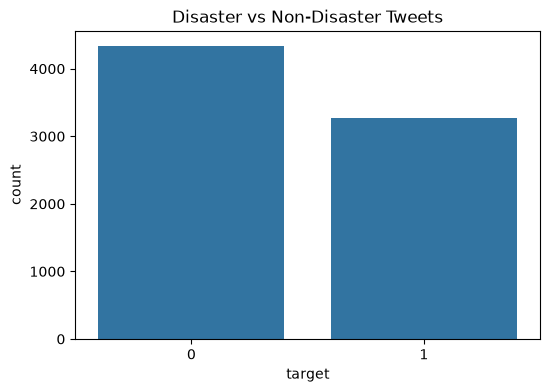

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)

plt.title('Disaster vs Non-Disaster Tweets')
plt.show()


Percentage Distribution

In [16]:
df['target'].value_counts(normalize=True)*100

target
0    57.034021
1    42.965979
Name: proportion, dtype: float64

Tweet Length Analysis

In [17]:
df['tweet_length'] = df['text'].apply(len)

df['tweet_length'].describe()

count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: tweet_length, dtype: float64

Tweet Length Histogram

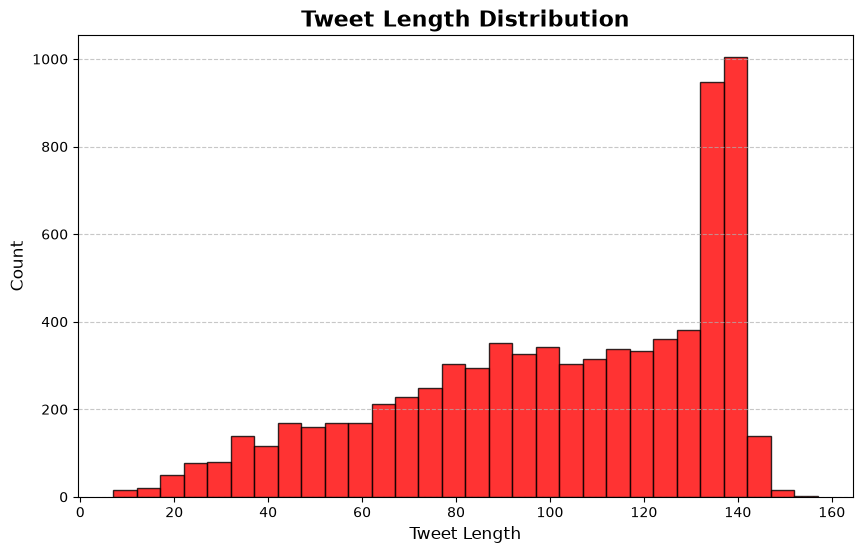

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df['tweet_length'],
    bins=30,
    color='red',      # Bar color
    edgecolor='black',    # Border color
    alpha=0.8             # Transparency
)

plt.title('Tweet Length Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Tweet Length', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [19]:
disaster_tweets = df[df['target']==1]

Most Common Words

In [20]:
from collections import Counter

all_words = " ".join(disaster_tweets['text'])

words = all_words.split()

Counter(words).most_common(20)

[('the', 1051),
 ('in', 1037),
 ('of', 888),
 ('a', 730),
 ('to', 706),
 ('and', 462),
 ('-', 389),
 ('on', 386),
 ('for', 368),
 ('is', 302),
 ('at', 273),
 ('I', 259),
 ('The', 257),
 ('by', 244),
 ('from', 206),
 ('A', 167),
 ('that', 166),
 ('with', 159),
 ('was', 158),
 ('are', 150)]

# Part 1 - Task 2: Data Preparation

Import Libraries

In [21]:
import re
import string

Cleaning Function

In [22]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^\w\s]", "", text)

    return text

Apply Cleaning

In [23]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",13000 people receive wildfires evacuation orde...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


Tokenization

In [24]:
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SHREE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SHREE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SHREE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

df[['clean_text','tokens']].head()

,clean_text,tokens
0,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth..."
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]"
2,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place..."
3,13000 people receive wildfires evacuation orde...,"[13000, people, receive, wildfires, evacuation..."
4,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala..."


Train Test Split

In [27]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6090,)
(1523,)


# Part 2 - Feature Engineering



 TF-IDF Feature Extraction


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [30]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(6090, 5000)
(1523, 5000)


Additional Features
Tweet Length

In [31]:
df['tweet_length'] = df['text'].apply(len)

Hashtag Count

In [32]:
df['hashtag_count'] = df['text'].apply(
    lambda x: x.count('#')
)

Mention Count

In [33]:
df['mention_count'] = df['text'].apply(
    lambda x: x.count('@')
)

Sentiment Analysis

In [34]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [35]:
from textblob import TextBlob

In [36]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [37]:
df['sentiment'] = df['clean_text'].apply(get_sentiment)

Part 2 - Model Selection

Model 1: Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

Model 2: Naive Bayes

In [39]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

Model 3: Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

rf_pred = rf.predict(X_test_tfidf)

Cross Validation

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_train_tfidf,
    y_train,
    cv=5
)

print(scores)
print(scores.mean())

[0.80213465 0.80706076 0.81116585 0.77914614 0.80295567]
0.8004926108374384


Hyperparameter Tuning

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
param_grid = {
    'C':[0.01,0.1,1,10]
}

In [44]:
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yie

Best Parameter:

In [45]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 1}
0.7431444879160122


Part 3: Model Evaluation


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

import matplotlib.pyplot as plt

Logistic Regression

In [47]:
print("Accuracy :", accuracy_score(y_test, lr_pred))

Accuracy : 0.8063033486539725


Naive Bayes:

In [48]:
print("Accuracy :", accuracy_score(y_test, nb_pred))

Accuracy : 0.8056467498358503


Random Forest

In [49]:
print("Accuracy :", accuracy_score(y_test, rf_pred))

Accuracy : 0.7760998030203545


Precision

In [50]:
print("Precision :", precision_score(y_test, lr_pred))

Precision : 0.8206521739130435


Recall

In [51]:
print("Recall :", recall_score(y_test, lr_pred))

Recall : 0.6979969183359014


F1 Score

In [52]:
print("F1 Score :", f1_score(y_test, lr_pred))

F1 Score : 0.7543713572023314


Classification Report

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       874
           1       0.82      0.70      0.75       649

    accuracy                           0.81      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.81      0.81      0.80      1523



Confusion Matrix

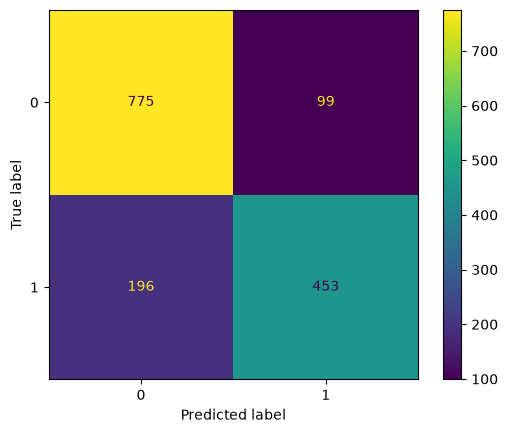

In [54]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

ROC Curve



In [55]:
lr_prob = lr.predict_proba(X_test_tfidf)[:,1]

ROC Points

In [56]:
fpr, tpr, threshold = roc_curve(y_test, lr_prob)

Plot:

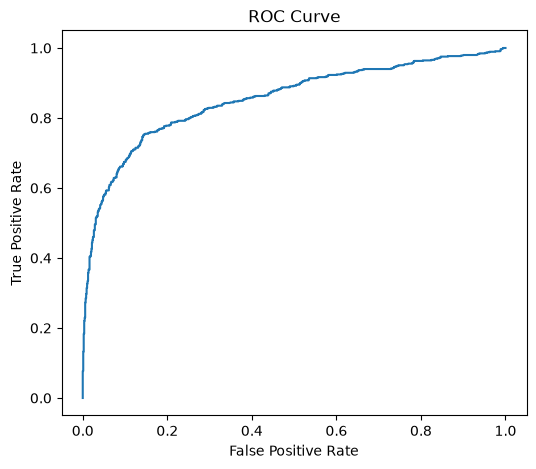

In [57]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

AUC Score

In [58]:
auc = roc_auc_score(y_test, lr_prob)

print("ROC AUC :", auc)

ROC AUC : 0.8540255559512433


Precision-Recall Curve

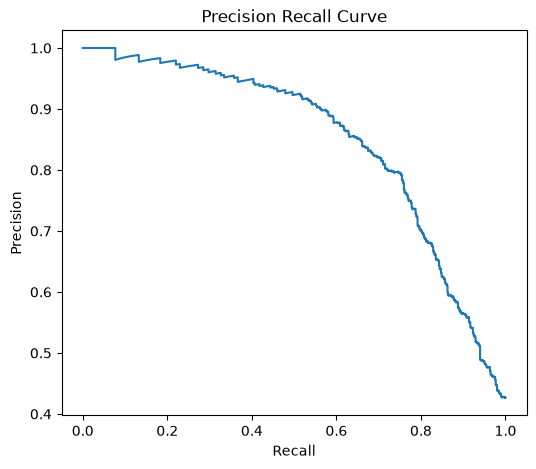

In [59]:
precision, recall, threshold = precision_recall_curve(y_test, lr_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

Compare All Models

In [60]:
results = {
    "Model": ["Logistic Regression",
              "Naive Bayes",
              "Random Forest"],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, rf_pred)
    ]
}

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806303,0.820652,0.697997,0.754371
1,Naive Bayes,0.805647,0.850895,0.659476,0.743056
2,Random Forest,0.776100,0.800781,0.631741,0.706288


Task: Model Validation

In [61]:
best_model = lr

 Testing Dataset on Prediction

In [62]:
y_pred = best_model.predict(X_test_tfidf)

Final Accuracy

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Testing Accuracy :", accuracy)

Testing Accuracy : 0.8063033486539725


Training Accuracy

In [64]:
train_pred = best_model.predict(X_train_tfidf)

train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy :", train_accuracy)

Training Accuracy : 0.874055829228243


Compare Training  and Testing Accuracy

In [65]:
print("Training Accuracy :", train_accuracy)

print("Testing Accuracy :", accuracy)

Training Accuracy : 0.874055829228243
Testing Accuracy : 0.8063033486539725


Classification Report

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       874
           1       0.82      0.70      0.75       649

    accuracy                           0.81      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.81      0.81      0.80      1523



Confusion Matrix

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[775  99]
 [196 453]]


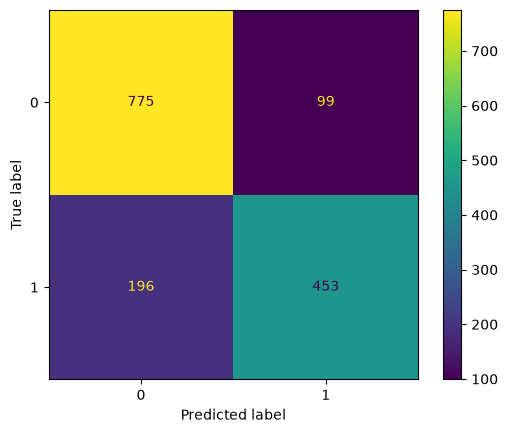

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [69]:
new_tweets = [
    "Massive earthquake destroyed several buildings",
    "I love watching football every weekend",
    "Flood water entered my house",
    "Happy Birthday my dear friend"
]

 Converted into TF-IDF 

In [70]:
new_tweets_tfidf = tfidf.transform(new_tweets)

In [71]:
prediction = best_model.predict(new_tweets_tfidf)

Result Print

In [72]:
for tweet, pred in zip(new_tweets, prediction):

    if pred == 1:
        print(tweet, "➡ Disaster Tweet")

    else:
        print(tweet, "➡ Non Disaster Tweet")

Massive earthquake destroyed several buildings ➡ Disaster Tweet
I love watching football every weekend ➡ Non Disaster Tweet
Flood water entered my house ➡ Non Disaster Tweet
Happy Birthday my dear friend ➡ Non Disaster Tweet


Part 4: Model Deployment

Model Saving (Pickle File)

In [73]:
import os
print(os.getcwd())

c:\Users\SHREE\Disaster_Tweet_Classification\notebooks


In [74]:
import os

os.makedirs("../models", exist_ok=True)

In [75]:
import pickle

# Save Model
with open("../models/disaster_model.pkl", "wb") as file:
    pickle.dump(lr, file)

# Save TF-IDF Vectorizer
with open("../models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Model Saved Successfully")

Model Saved Successfully
